# Pruebas VPM — Cadena completa desde BD

Ejecuta la cadena: **Índices EVI/LSWI → Whittaker → FPAR/W_scalar → GPP → NPP → Biomasa seca → Rendimiento → Producción**

Usa datos de `series_diarias_vpm` en el GeoPackage activo.

Replica el pipeline de producción (`flujos_trabajo.py` → `modulo_predictivo.py`):
- Índices cargados de SOS a EOS
- W_scalar usa `max(lswi_max_DB, series_max)` como el pipeline
- Clima reindexado a fechas EVI
- GPP recortado a [SOS, EOS]

In [1]:
# ── 1. Imports ────────────────────────────────────────────────────────────────
import sys
sys.path.append("..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from pipeline.ingesta import cargar_indices_desde_bd, cargar_clima_desde_bd
from pipeline.modulo_predictivo import construir_serie_climatica_prediccion
from pipeline.modulo_vpm import (
    preprocesar_indices_vpm,
    calcular_gpp_vpm,
    calcular_biomasa_y_rendimiento,
)
from utils.conexionDB import set_db_path, get_db_path, get_connection_raw
from utils.graficas import graficar_whittaker_sos
from config import GPKG_PATH, GPKG_PRUEBAS_PATH, DURACION_CICLO

2026-07-23 22:37:17.360 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-07-23 22:37:17.362 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-07-23 22:37:17.363 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-07-23 22:37:17.364 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-07-23 22:37:17.365 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-07-23 22:37:17.366 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-07-23 22:37:17.367 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-07-23 22:37:17.368 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-07-

In [2]:
# ── 2. Cambiar a BD de pruebas ────────────────────────────────────────────────
# Descomenta la línea que quieras usar:

# BD de pruebas
set_db_path(GPKG_PRUEBAS_PATH)

# BD real
# set_db_path(GPKG_PATH)

print(f"BD activa: {get_db_path()}")

BD activa: c:\Users\mayno\Desktop\SeminarioInvestigacion\segmentacion_clasificacion_estimacion_maiz_comayagua\notebooks\..\data\pipeline_pruebas.gpkg


In [ ]:
graficar_whittaker_sos('2025-01-01','2026-07-17')

In [24]:
# ── 4. Seleccionar ciclo — la parcela se obtiene automáticamente ────────────
ID_CICLO = 2654  # ← CAMBIA al id_ciclo que quieras probar

ciclo_row = pd.read_sql("""
    SELECT id_ciclo, id_parcela, temporada, sos, eos,
           fecha_inicio, fecha_fin, lswi_max,
           rendimiento, produccion_total
    FROM produccion_acumulada_ciclo
    WHERE id_ciclo = ?
""", get_connection_raw(), params=(ID_CICLO,))

if ciclo_row.empty:
    raise ValueError(f"Ciclo {ID_CICLO} no encontrado en BD.")
ciclo_row = ciclo_row.iloc[0]

ID_PARCELA = int(ciclo_row["id_parcela"])
SOS_STR  = str(ciclo_row["sos"])
EOS_STR  = str(ciclo_row["eos"])
SEG_INICIO_STR = str(ciclo_row["fecha_inicio"])
SEG_FIN_STR    = str(ciclo_row["fecha_fin"])
LSWI_MAX_DB = ciclo_row.get("lswi_max")  # puede ser None

print(f"Parcela: {ID_PARCELA}  |  Ciclo #{ID_CICLO}: {ciclo_row['temporada']}")
print(f"  SOS: {SOS_STR} → EOS: {EOS_STR}")
print(f"  Segmento: {SEG_INICIO_STR} → {SEG_FIN_STR}")
print(f"  lswi_max DB: {LSWI_MAX_DB}")
print(f"  Rendimiento DB: {ciclo_row.get('rendimiento', '—')} qq/ha")
print(f"  Producción DB: {ciclo_row.get('produccion_total', '—')} qq")

Parcela: 10  |  Ciclo #2654: postrera
  SOS: 2025-09-13 → EOS: 2026-01-06
  Segmento: 2025-08-26 → 2026-01-06
  lswi_max DB: None
  Rendimiento DB: 85.21016514716035 qq/ha
  Producción DB: 8.638008712964185 qq


In [14]:
ID_PARCELA = 15
SOS_STR  = "2025-06-18"
EOS_STR  = "2025-11-10"
SEG_INICIO_STR = "2025-06-10"
SEG_FIN_STR    = EOS_STR
LSWI_MAX_DB = None # puede ser None

In [25]:
# ── 6. Cargar índices EVI/LSWI desde BD (SOLO [SOS, EOS] como el pipeline) ──
dfs_crudos = cargar_indices_desde_bd(
    fecha_inicio=SOS_STR,
    fecha_fin=EOS_STR,
    ids_parcelas=[ID_PARCELA],
)
col = f"id_{ID_PARCELA}"
print(f"\nEVI crudo: {len(dfs_crudos['EVI'])} fechas")
print(f"LSWI crudo: {len(dfs_crudos['LSWI'])} fechas")
display(dfs_crudos["EVI"].head())

OK  Indices cargados desde BD: 116 fechas x 1 parcelas (2025-09-13 -> 2026-01-06).

EVI crudo: 116 fechas
LSWI crudo: 116 fechas


,id_10
2025-09-13,NaN
2025-09-14,NaN
2025-09-15,NaN
2025-09-16,NaN
2025-09-17,0.269579


In [26]:
# ── 7. Preprocesar: Whittaker + FPAR + W_scalar ──────────────────────────────
# lswi_max: replicamos max(DB_val, series_max) del pipeline (modulo_predictivo.py:695-699)
lswi_max_val = LSWI_MAX_DB  # puede ser None
dfs_vpm = preprocesar_indices_vpm(
    dfs_vpm_crudos=dfs_crudos,
    lambda_param=4000.0,
    lswi_max={ID_PARCELA: lswi_max_val} if lswi_max_val is not None else None,
)

# El pipeline usa max(DB_val, series_max) — verificar si la serie supera al DB
lswi_series_max = float(dfs_vpm["LSWI"][col].max())
if lswi_max_val is not None and lswi_series_max > lswi_max_val:
    print(f"  ℹ️ series_max ({lswi_series_max:.3f}) > DB_lswi_max ({lswi_max_val:.3f}), "
          f"recalculando W_scalar con max = {lswi_series_max:.3f}")
    lswi_max_usado = max(lswi_max_val, lswi_series_max)
    dfs_vpm = preprocesar_indices_vpm(
        dfs_vpm_crudos=dfs_crudos,
        lambda_param=4000.0,
        lswi_max={ID_PARCELA: lswi_max_usado},
    )
else:
    lswi_max_usado = lswi_series_max if lswi_max_val is None else lswi_max_val

print(f"\nlswi_max usado: {lswi_max_usado:.3f}")
print(f"EVI suavizado: {dfs_vpm['EVI'][col].dropna().shape[0]} días")
print(f"LSWI suavizado: {dfs_vpm['LSWI'][col].dropna().shape[0]} días")
print(f"FPAR (min/max): {dfs_vpm['FPAR'][col].min():.3f} / {dfs_vpm['FPAR'][col].max():.3f}")
print(f"W_scalar (min/max): {dfs_vpm['W_scalar'][col].min():.3f} / {dfs_vpm['W_scalar'][col].max():.3f}")

Suavizando serie temporal para: EVI...
Suavizando serie temporal para: LSWI...

Calculando FPAR y Factor de Estres Hidrico Diario (W_scalar)...

OK Metricas base del VPM calculadas y consolidadas a nivel DIARIO:
   - Total de Parcelas Procesadas: 1
   - FPAR Diario (Max Global): 0.500
   - W_scalar Diario (Min/Max Global): 0.571 / 1.000

lswi_max usado: 0.448
EVI suavizado: 116 días
LSWI suavizado: 116 días
FPAR (min/max): 0.192 / 0.500
W_scalar (min/max): 0.571 / 1.000


In [27]:
# ── 8. Cargar clima desde BD y reindexar a fechas EVI (como el pipeline) ────
# El pipeline carga clima desde fecha_inicio_str hasta fecha_hoy (EOS),
# construye serie diaria con climatología para gaps y reindexa a fechas EVI.
fechas_evi = dfs_vpm["EVI"][col].dropna().index

dfs_clima_raw = cargar_clima_desde_bd(
    fecha_inicio=SEG_INICIO_STR,
    fecha_fin=EOS_STR,
    ids_parcelas=[ID_PARCELA],
)

# Climatología diaria (promedio histórico)
doy = pd.Series(dfs_clima_raw["temperature-mean"][col].dropna())
clima_temp = doy.groupby(doy.index.dayofyear).mean()
doy = pd.Series(dfs_clima_raw["solar-radiation-flux"][col].dropna())
clima_rad = doy.groupby(doy.index.dayofyear).mean()

# Construir serie completa y reindexar a fechas EVI
serie_temp_completa = construir_serie_climatica_prediccion(
    pd.Timestamp(SEG_INICIO_STR),
    pd.Timestamp(EOS_STR),
    dfs_clima_raw["temperature-mean"][col].dropna(),
    clima_temp,
).reindex(fechas_evi)

serie_rad_completa = construir_serie_climatica_prediccion(
    pd.Timestamp(SEG_INICIO_STR),
    pd.Timestamp(EOS_STR),
    dfs_clima_raw["solar-radiation-flux"][col].dropna(),
    clima_rad,
).reindex(fechas_evi)

dfs_clima = {
    "temperature-mean": pd.DataFrame({col: serie_temp_completa}),
    "solar-radiation-flux": pd.DataFrame({col: serie_rad_completa}),
}

print(f"Temperatura (min/max): {serie_temp_completa.min():.2f} / {serie_temp_completa.max():.2f}")
print(f"Radiación (min/max): {serie_rad_completa.min():.0f} / {serie_rad_completa.max():.0f}")
print(f"Días con clima: {len(serie_temp_completa)}")

OK  Clima cargado desde BD: 134 fechas x 1 parcelas (2025-08-26 -> 2026-01-06).
Temperatura (min/max): 16.32 / 23.43
Radiación (min/max): 5169052 / 21423506
Días con clima: 116


In [28]:
# ── 9. Calcular GPP (VPM) ─────────────────────────────────────────────────────
dfs_gpp = calcular_gpp_vpm(
    dfs_vegetacion=dfs_vpm,
    dfs_clima=dfs_clima,
)

gpp = dfs_gpp["GPP"][col]
print(f"GPP diario — media: {gpp.mean():.3f}, máx: {gpp.max():.3f}, total: {gpp.sum():.1f} g C/m²")


OK Pipeline VPM DIARIO COMPLETADO EXITOSAMENTE!
   - Horizonte temporal continuo evaluado: 116 dias.
   - Temperatura media registrada en la zona: 21.05 C
   - GPP Promedio diario del Maiz: 6.248 g C/m2/dia
   - GPP Maximo diario alcanzado: 12.11 g C/m2/dia
GPP diario — media: 6.248, máx: 12.109, total: 724.7 g C/m²


In [29]:
# ── 10. Calcular NPP → Biomasa → Rendimiento ─────────────────────────────────
# Recortar GPP al período [SOS, EOS] como hace el pipeline (modulo_predictivo.py:767)
df_gpp_ciclo = dfs_gpp["GPP"][[col]].loc[SOS_STR:EOS_STR].dropna()

if df_gpp_ciclo.empty:
    raise ValueError("No hay GPP válido en [SOS, EOS] para calcular biomasa/rendimiento.")

resultado = calcular_biomasa_y_rendimiento(
    df_gpp_recortado=df_gpp_ciclo,
    harvest_index=0.61,  
)

npp = resultado["npp_diario"][col]
biomasa = resultado["biomasa_acumulada"][col]
yield_tha = resultado["yield_final_tha"][col]

print(f"NPP total: {npp.sum():.1f} g C/m²")
print(f"Biomasa final: {biomasa.iloc[-1]:.1f} g DM/m²")
print(f"Rendimiento: {yield_tha:.2f} t/ha")

# Conversión a quintales/hectárea (1 t = 22.0458 qq)
qq_ha = yield_tha * 22.0458
area_row = pd.read_sql(
    "SELECT area_ha FROM parcelas_vigentes WHERE id_parcela = ?",
    get_connection_raw(), params=(ID_PARCELA,)
)
area_ha = area_row["area_ha"].iloc[0] if not area_row.empty else 0.0
qq_parcela = qq_ha * area_ha

print(f"Rendimiento: {qq_ha:.1f} qq/ha")
print(f"Producción total: {qq_parcela:.1f} qq (área: {area_ha:.2f} ha)")

# Conversión a qq/manzana (1 mz = 0.6989 ha)
HA_X_MZ = 0.6989
qq_mz = qq_ha * HA_X_MZ
print(f"Rendimiento: {qq_mz:.1f} qq/mz")

NPP total: 362.4 g C/m²
Biomasa final: 805.2 g DM/m²
Rendimiento: 4.91 t/ha
Rendimiento: 108.3 qq/ha
Producción total: 11.0 qq (área: 0.10 ha)
Rendimiento: 75.7 qq/mz


In [30]:
# ── 11. Resultados resumen ────────────────────────────────────────────────────
from IPython.display import display, HTML

cuadro = f"""
<table style='font-size:14px;'>
  <tr><th colspan='2'>Resumen — Parcela {ID_PARCELA} · Ciclo {ID_CICLO}</th></tr>
  <tr><td>Periodo</td><td>{SOS_STR} → {EOS_STR}</td></tr>
  <tr><td>GPP acumulado</td><td>{gpp.sum():.1f} g C/m²</td></tr>
  <tr><td>NPP acumulado</td><td>{npp.sum():.1f} g C/m²</td></tr>
  <tr><td>Biomasa seca final</td><td>{biomasa.iloc[-1]:.1f} g DM/m²</td></tr>
  <tr><td>Yield</td><td>{yield_tha:.2f} t/ha</td></tr>
  <tr><td>Rendimiento</td><td>{qq_ha:.1f} qq/ha</td></tr>
  <tr><td>Rendimiento</td><td>{qq_mz:.1f} qq/mz</td></tr>
  <tr><td>Producción total</td><td>{qq_parcela:.1f} qq</td></tr>
  <tr><td>Rend. DB</td><td>{ciclo_row.get('rendimiento', '—')} qq/ha</td></tr>
  <tr><td>Prod. DB</td><td>{ciclo_row.get('produccion_total', '—')} qq</td></tr>
</table>
"""
display(HTML(cuadro))

In [31]:
# # ── 12. Visualizaciones separadas ──────────────────────────────────────────────
date_fmt = mdates.DateFormatter("%b\n%Y")
locator = mdates.MonthLocator()

# # ─── Fig 1: EVI + LSWI ──────────────────────────────────────────────────────────
# fig1, ax1 = plt.subplots(figsize=(14, 5))
# ax1.plot(dfs_vpm["EVI"].index, dfs_vpm["EVI"][col], "g-", lw=1.2, label="EVI")
# ax1.plot(dfs_vpm["LSWI"].index, dfs_vpm["LSWI"][col], "b-", lw=1.2, label="LSWI")
# ax1.set_ylabel("Índice")
# ax1.legend(loc="upper right")
# ax1.set_title(f"EVI / LSWI suavizados  — Parcela {ID_PARCELA} — Ciclo {ID_CICLO}", fontsize=12)
# ax1.grid(True, alpha=0.3)
# ax1.xaxis.set_major_locator(locator)
# ax1.xaxis.set_major_formatter(date_fmt)
# plt.tight_layout()
# plt.savefig("vpm_evi_lswi.pdf", format="pdf", bbox_inches="tight")
# plt.show()

# # ─── Fig 2: W_scalar ────────────────────────────────────────────────────────────
# fig2, ax2 = plt.subplots(figsize=(14, 4))
# ax2.plot(dfs_vpm["W_scalar"].index, dfs_vpm["W_scalar"][col], "c-", lw=1.2)
# ax2.fill_between(dfs_vpm["W_scalar"].index, dfs_vpm["W_scalar"][col], alpha=0.3, color="cyan")
# ax2.set_ylabel("W_scalar")
# ax2.set_title(f"Factor de Estrés Hídrico (W_scalar)  — Parcela {ID_PARCELA} — Ciclo {ID_CICLO}", fontsize=12)
# ax2.grid(True, alpha=0.3)
# ax2.xaxis.set_major_locator(locator)
# ax2.xaxis.set_major_formatter(date_fmt)
# plt.tight_layout()
# plt.savefig("vpm_wscalar.pdf", format="pdf", bbox_inches="tight")
# plt.show()

# # ─── Fig 3: T_scalar ────────────────────────────────────────────────────────────
# fig3, ax3 = plt.subplots(figsize=(14, 4))
# ax3.plot(dfs_gpp["T_scalar"].index, dfs_gpp["T_scalar"][col], "r-", lw=1.2)
# ax3.fill_between(dfs_gpp["T_scalar"].index, dfs_gpp["T_scalar"][col], alpha=0.3, color="red")
# ax3.set_ylabel("T_scalar")
# ax3.set_title(f"Escalar de Temperatura (T_scalar)  — Parcela {ID_PARCELA} — Ciclo {ID_CICLO}", fontsize=12)
# ax3.grid(True, alpha=0.3)
# ax3.xaxis.set_major_locator(locator)
# ax3.xaxis.set_major_formatter(date_fmt)
# plt.tight_layout()
# plt.savefig("vpm_tscalar.pdf", format="pdf", bbox_inches="tight")
# plt.show()

# # ─── Fig 4: GPP diario ──────────────────────────────────────────────────────────
# fig4, ax4 = plt.subplots(figsize=(14, 5))
# ax4.fill_between(gpp.index, gpp.values, alpha=0.4, color="forestgreen")
# ax4.plot(gpp.index, gpp.values, "g-", lw=1.0)
# ax4.set_ylabel("GPP (g C/m²/día)")
# ax4.set_title(f"Producción Primaria Bruta (VPM)  — Parcela {ID_PARCELA} — Ciclo {ID_CICLO}", fontsize=12)
# ax4.grid(True, alpha=0.3)
# ax4.xaxis.set_major_locator(locator)
# ax4.xaxis.set_major_formatter(date_fmt)
# plt.tight_layout()
# plt.savefig("vpm_gpp.pdf", format="pdf", bbox_inches="tight")
# plt.show()

# # ─── Fig 5: Biomasa acumulada ───────────────────────────────────────────────────
# fig5, ax5 = plt.subplots(figsize=(14, 5))
# ax5.fill_between(biomasa.index, biomasa.values, alpha=0.4, color="saddlebrown")
# ax5.plot(biomasa.index, biomasa.values, "brown", lw=1.2)
# ax5.set_ylabel("Biomasa (g DM/m²)")
# ax5.set_title(f"Biomasa acumulada — Yield: {qq_mz:.1f} qq/mz | Prod: {qq_parcela:.1f} qq — Parcela {ID_PARCELA} — Ciclo {ID_CICLO}", fontsize=12)
# ax5.grid(True, alpha=0.3)
# ax5.xaxis.set_major_locator(locator)
# ax5.xaxis.set_major_formatter(date_fmt)
# plt.tight_layout()
# plt.savefig("vpm_biomasa.pdf", format="pdf", bbox_inches="tight")
# plt.show()

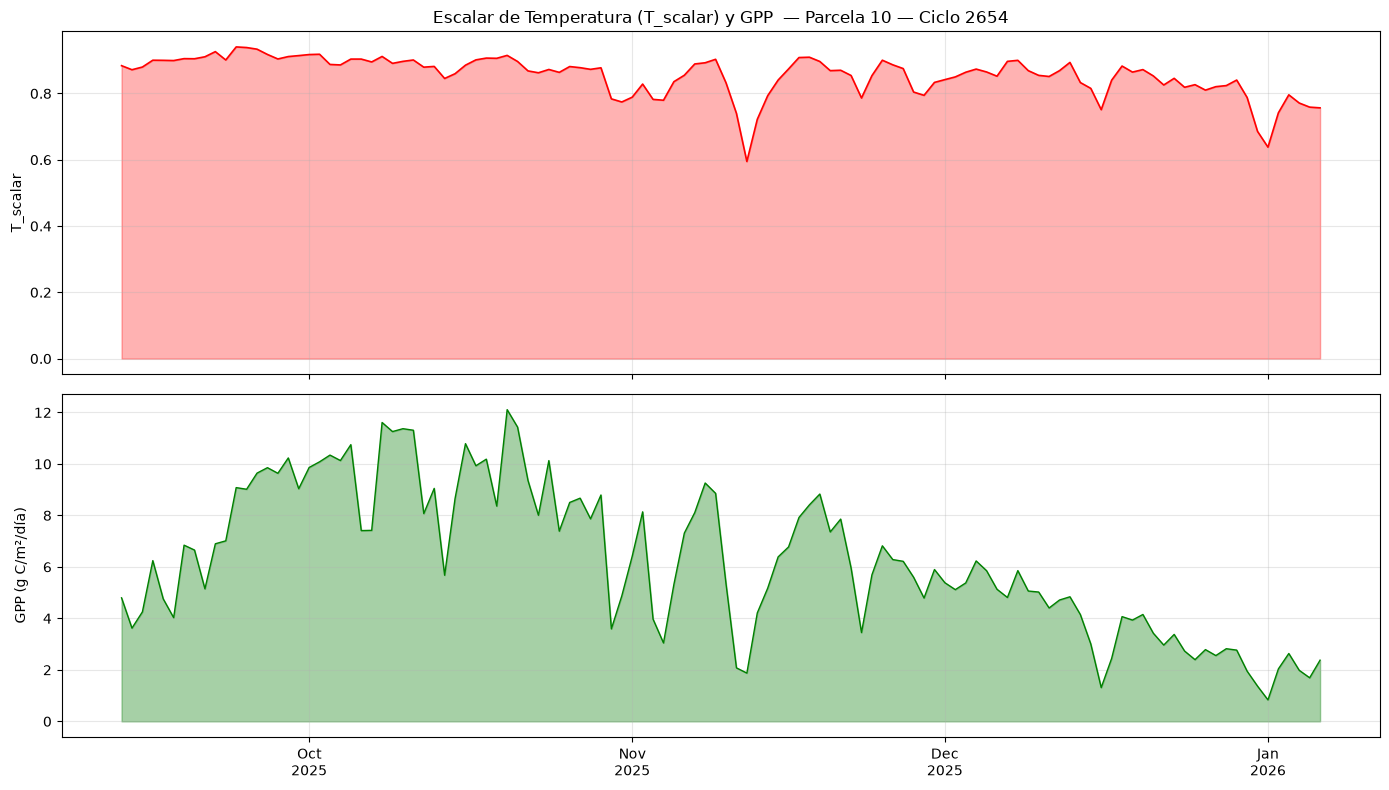

In [32]:
# # ── 12. Visualizaciones combinadas: T_scalar y GPP ─────────────────────────────
date_fmt = mdates.DateFormatter("%b\n%Y")
locator = mdates.MonthLocator()

# Crear 2 subgráficas apiladas verticalmente, compartiendo el eje X
fig, (ax3, ax4) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# ─── Gráfica Arriba: T_scalar ───────────────────────────────────────────────────
ax3.plot(dfs_gpp["T_scalar"].index, dfs_gpp["T_scalar"][col], "r-", lw=1.2)
ax3.fill_between(dfs_gpp["T_scalar"].index, dfs_gpp["T_scalar"][col], alpha=0.3, color="red")
ax3.set_ylabel("T_scalar")
ax3.set_title(f"Escalar de Temperatura (T_scalar) y GPP  — Parcela {ID_PARCELA} — Ciclo {ID_CICLO}", fontsize=12)
ax3.grid(True, alpha=0.3)

# ─── Gráfica Abajo: GPP diario ──────────────────────────────────────────────────
ax4.fill_between(gpp.index, gpp.values, alpha=0.4, color="forestgreen")
ax4.plot(gpp.index, gpp.values, "g-", lw=1.0)
ax4.set_ylabel("GPP (g C/m²/día)")
ax4.grid(True, alpha=0.3)

# Configuración del eje X (se aplica solo al gráfico inferior por el sharex=True)
ax4.xaxis.set_major_locator(locator)
ax4.xaxis.set_major_formatter(date_fmt)

plt.tight_layout()
plt.savefig("vpm_tscalar_gpp_combinado.pdf", format="pdf", bbox_inches="tight")
plt.show()

---
### Notas
- Cambia `ID_PARCELA` e `ID_CICLO` en la celda 4/5 para probar otras.
- Cambia `set_db_path()` en la celda 2 para alternar entre BD real/pruebas.
- Para ver el efecto de parámetros VPM, pasa kwargs a `calcular_gpp_vpm()` (celda 9) y `calcular_biomasa_y_rendimiento()` (celda 10).
- La conversión a qq usa el factor 22.0458 (1 t = 22.0458 qq).